In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/data.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['TotalCharges'][:5]

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

### TotalCharges Data Type

The `TotalCharges` column has an `object` data type, but it contains numerical values. Therefore, it needs to be converted to a numeric data type for proper analysis and model training.

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors='coerce')
df['TotalCharges'][:5]

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

Converted `TotalCharges` from object to numeric using `pd.to_numeric(errors='coerce')`, which transformed invalid or blank values into `NaN` for further preprocessing.


In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Handling Missing Values in TotalCharges

After converting `TotalCharges` to a numeric data type, 11 missing values were identified. These records correspond to customers with zero tenure, indicating that no charges had been accumulated yet. Therefore, the missing values were replaced with 0 to preserve the records and avoid unnecessary data loss.

In [10]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [11]:
df[df['tenure'] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [12]:
df["TotalCharges"].fillna(0, inplace=True)

In [13]:
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.1 KB


In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [17]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [18]:
categorical_columns = ['gender','Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Churn']


numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']


In [19]:
print("+++++++++++++++++VALUE COUNTS+++++++++++++++++")
for col in categorical_columns:
    print("="*40)
    print(df[col].value_counts())

+++++++++++++++++VALUE COUNTS+++++++++++++++++
gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: 

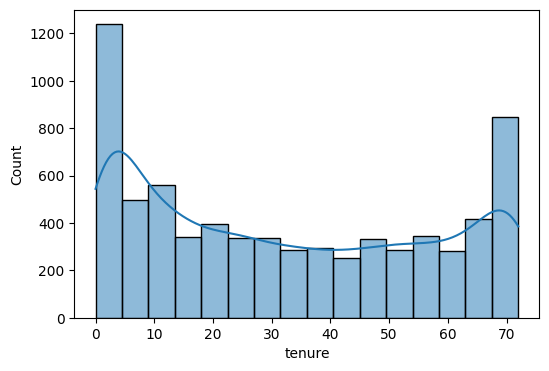

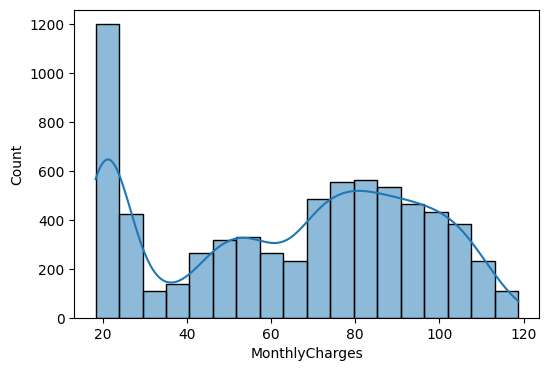

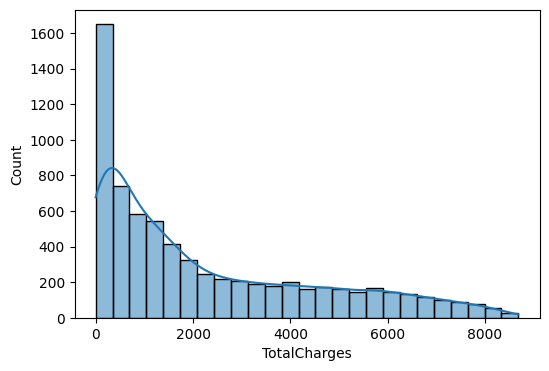

In [20]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)
    plt.show()

# Numerical Features Analysis

## 1. Tenure

### Observation

* Tenure exhibits a bimodal (U-shaped) distribution.
* A large number of customers have very low tenure (0–10 months).
* Another large group of customers has high tenure (60–72 months).
* Relatively fewer customers fall in the middle tenure range.

### Insight

* Customers tend to be either newly acquired or long-term loyal customers.
* Customer retention appears stronger after the initial months of service.

---

## 2. MonthlyCharges

### Observation

* MonthlyCharges shows a multimodal distribution.
* Values range approximately from $20 to $120.
* Multiple peaks are observed across the distribution.

### Insight

* The presence of multiple peaks indicates different customer segments.
* Different service plans and subscription packages likely contribute to varying monthly charges.

---

## 3. TotalCharges

### Observation

* TotalCharges is positively skewed (right-skewed).
* Most customers have relatively low total charges.
* A smaller number of customers have very high total charges.

### Insight

* Many customers are relatively new, resulting in lower accumulated charges.
* Long-term customers accumulate significantly higher total charges over time.


In [21]:
df[numerical_columns].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


In [22]:
(df['Churn'].value_counts(normalize=True)*100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**Class Imbalance:** The target variable `Churn` is imbalanced, with approximately **73.46%** non-churn customers and **26.54%** churn customers, which may bias machine learning models toward the majority class.


In [23]:
df.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


In [24]:
def churn_rate(col):
    df.groupby(col)['Churn']
    return df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100)

print(churn_rate('Contract'))
print("="*30)
print(churn_rate('InternetService'))
print("="*30)
print(churn_rate('PaymentMethod'))

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64
InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64


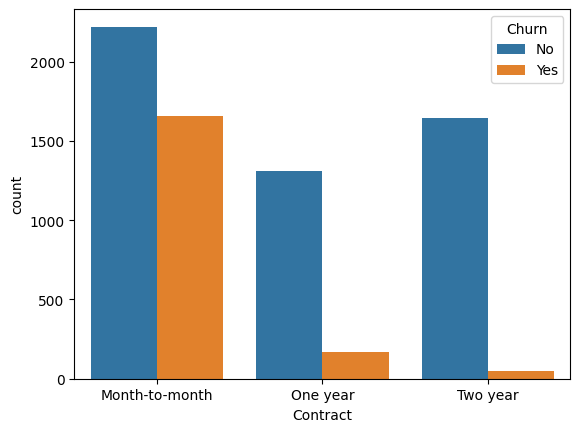

In [25]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

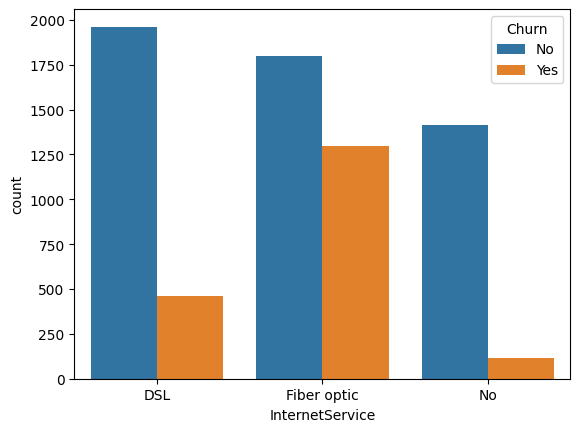

In [26]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

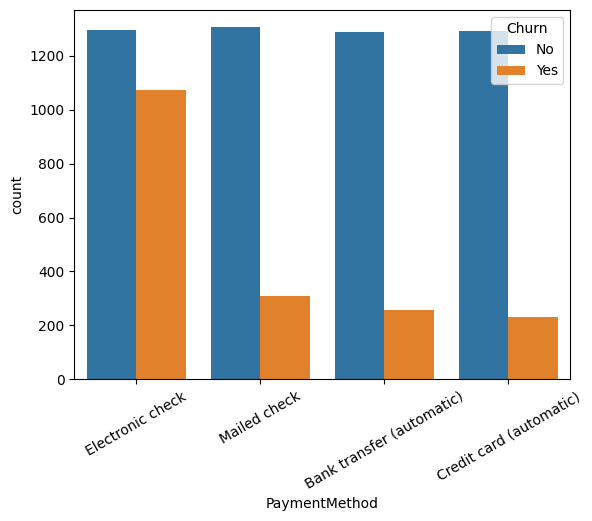

In [27]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

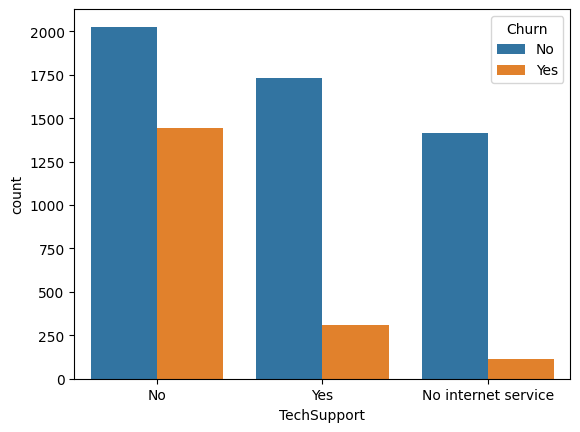

In [28]:
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.show()

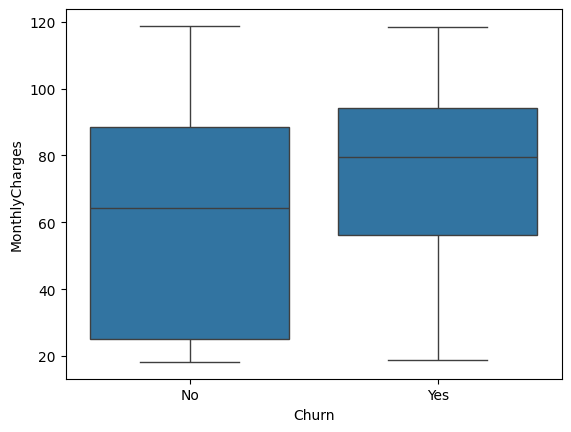

In [29]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

### MonthlyCharges vs Churn

- Churned customers have a higher median MonthlyCharges than non-churned customers.
- Higher monthly charges appear to be associated with increased churn.
- No major outliers are observed in the data.
- MonthlyCharges is likely an important predictor of customer churn.

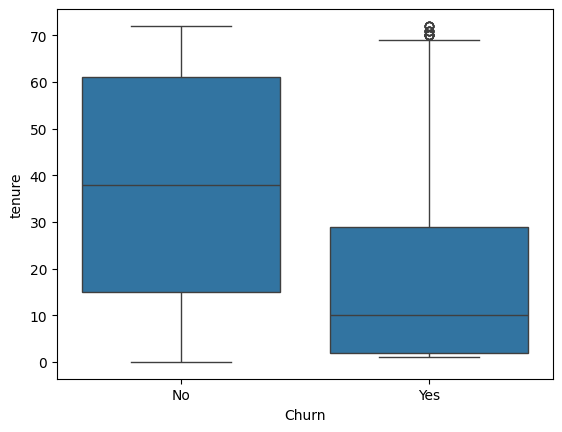

In [30]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

### Tenure vs Churn

- Churned customers have a much lower median tenure than non-churned customers.
- Customers with shorter tenure are more likely to churn.
- A few high-tenure churned customers appear as outliers.
- Tenure is an important feature for predicting customer churn.

In [31]:
df[['MonthlyCharges','TotalCharges']].quantile([0.01, 0.99])

,MonthlyCharges,TotalCharges
0.01,19.200,19.750
0.99,114.729,8039.256


### Outlier Check Using Quantiles

- The 1st and 99th percentiles were calculated for MonthlyCharges and TotalCharges.
- MonthlyCharges ranges from approximately 18.25 to 118.75, while the 1st and 99th percentiles are 19.20 and 114.73, indicating no significant extreme values.
- TotalCharges ranges from approximately 18.80 to 8684.80, while the 1st and 99th percentiles are 19.75 and 8039.26.
- Higher TotalCharges values are expected for customers with longer tenure and do not indicate data anomalies.
- No outlier removal was performed, as the extreme values represent valid customer behavior rather than data errors.

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

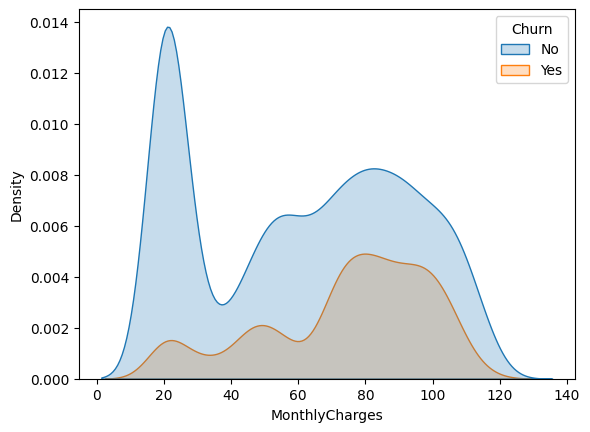

In [32]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)

### MonthlyCharges Distribution by Churn

- Churned customers are more concentrated in the higher MonthlyCharges range.
- Non-churned customers have a strong presence at lower MonthlyCharges values.
- The distributions overlap, indicating that MonthlyCharges alone does not fully explain churn.
- MonthlyCharges is likely an important feature for customer churn prediction.

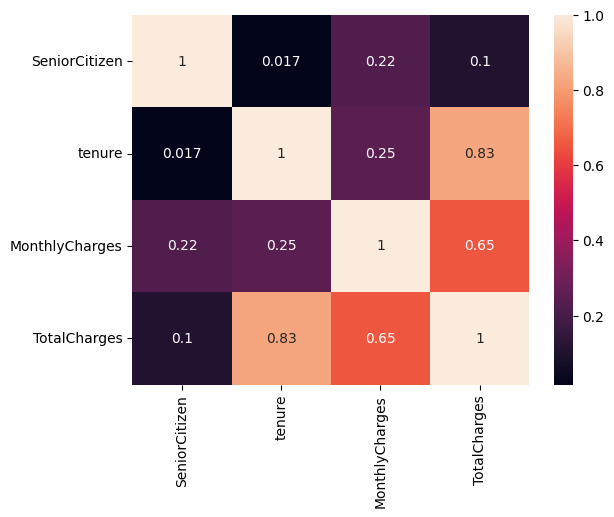

In [33]:
sns.heatmap(df.corr(numeric_only=True) , annot=True)
plt.show()

In [34]:
df.to_csv(
    'data/churn_cleaned.csv',
    index=False
)

## EDA Insights

- Customers with **month-to-month contracts** have the highest churn rate  
- **Low-tenure customers** are more likely to churn  
- **Higher monthly charges** increase churn probability  
- **Electronic check** users show higher churn than other payment methods  
- **Tenure and TotalCharges** are strongly correlated  
- Dataset shows **class imbalance** (73% No, 27% Yes)

